In [ ]:
import polars as pl

df = pl.read_ndjson("../data/onsets.jsonl").with_columns(
    pl.col("onset").str.split(" ").alias("phonemes")
)

In [ ]:
print("single consonants")

iter = (
    df.filter(pl.col("phonemes").list.len() == 1)
    .sort(pl.col("count"))
    .select(pl.col("phonemes").list.get(0), pl.col("count"))
    .iter_rows()
)
for i, row in enumerate(iter):
    print(f"{i:02}) {row[0]}\t{row[1]}")

print("double consonants")

iter = (
    df.filter(pl.col("phonemes").list.len() == 2)
    .sort(pl.col("count"))
    .select(pl.col("phonemes"), pl.col("count"))
    .iter_rows()
)
for i, row in enumerate(iter):
    print(f"{i:02}) {row[0]}\t{row[1]}")

print("triple consonants")

iter = (
    df.filter(pl.col("phonemes").list.len() == 3)
    .sort(pl.col("count"))
    .select(pl.col("phonemes"), pl.col("count"))
    .iter_rows()
)
for i, row in enumerate(iter):
    print(f"{i:02}) {row[0]}\t{row[1]}")

single consonants
00) ZH	109617
01) TH	172743
02) Y	387251
03) CH	426134
04) Z	605137
05) G	667096
06) JH	796695
07) SH	1151570
08) V	1207967
09) P	1419986
10) HH	1686337
11) F	1891874
12) N	2074883
13) B	2169705
14) M	2253262
15) K	2326864
16) L	2372097
17) D	2400310
18) R	2488335
19) S	2677571
20) W	2995855
21) T	5622843
22) DH	8353551
double consonants
00) ['S', 'HH']	1
01) ['D', 'Z']	1
02) ['DH', 'Y']	1
03) ['N', 'D']	1
04) ['D', 'N']	1
05) ['HH', 'L']	1
06) ['P', 'SH']	1
07) ['CH', 'W']	1
08) ['R', 'W']	3
09) ['SH', 'V']	3
10) ['TH', 'Y']	3
11) ['HH', 'M']	10
12) ['Y', 'W']	16
13) ['HH', 'R']	31
14) ['CH', 'Y']	166
15) ['K', 'V']	273
16) ['TH', 'S']	310
17) ['Z', 'Y']	351
18) ['F', 'N']	417
19) ['SH', 'T']	487
20) ['G', 'D']	583
21) ['S', 'V']	589
22) ['Z', 'V']	620
23) ['V', 'W']	964
24) ['F', 'W']	1017
25) ['P', 'W']	1222
26) ['S', 'Y']	1270
27) ['B', 'W']	1531
28) ['SH', 'W']	1615
29) ['Z', 'W']	2686
30) ['S', 'R']	2824
31) ['K', 'M']	2864
32) ['SH', 'R']	3016
33) ['Z', 'B']	32

In [7]:
import numpy as np

consonants = (
    df.filter(pl.col("phonemes").list.len() == 1)
    .sort(pl.col("count"))
    .select(
        pl.col("phonemes").list.get(0),
    )
    .to_series()
    .to_list()
)

pairs = []
for c in consonants:
    l = (
        df.filter(pl.col("phonemes").list.len() > 1)
        .filter(pl.col("phonemes").list.contains(c))
        .select(pl.col("phonemes"))
        .to_series()
        .to_list()
    )
    l = np.concat(l).tolist()
    l = np.unique(l).tolist()
    l.remove(c)

    pairs.append({"left": c, "right": l})

iter = pl.DataFrame(pairs).sort(pl.col("right").list.len()).iter_rows()
for row in iter:
    print(f"{row[0]:2s} ({len(row[1])})\t{row[1]}")

ZH (1)	['W']
JH (1)	['Y']
DH (1)	['Y']
CH (2)	['W', 'Y']
TH (4)	['R', 'S', 'W', 'Y']
G  (5)	['D', 'L', 'R', 'W', 'Y']
Z  (6)	['B', 'D', 'L', 'V', 'W', 'Y']
P  (6)	['L', 'R', 'S', 'SH', 'W', 'Y']
HH (6)	['L', 'M', 'R', 'S', 'W', 'Y']
F  (6)	['L', 'N', 'R', 'S', 'W', 'Y']
B  (6)	['L', 'M', 'R', 'W', 'Y', 'Z']
T  (6)	['L', 'R', 'S', 'SH', 'W', 'Y']
N  (7)	['D', 'F', 'K', 'S', 'SH', 'W', 'Y']
SH (8)	['L', 'M', 'N', 'P', 'R', 'T', 'V', 'W']
K  (8)	['L', 'M', 'N', 'R', 'S', 'V', 'W', 'Y']
D  (8)	['G', 'M', 'N', 'R', 'V', 'W', 'Y', 'Z']
V  (9)	['D', 'K', 'L', 'R', 'S', 'SH', 'W', 'Y', 'Z']
M  (9)	['B', 'D', 'HH', 'K', 'R', 'S', 'SH', 'W', 'Y']
L  (13)	['B', 'F', 'G', 'HH', 'K', 'P', 'S', 'SH', 'T', 'V', 'W', 'Y', 'Z']
S  (13)	['F', 'HH', 'K', 'L', 'M', 'N', 'P', 'R', 'T', 'TH', 'V', 'W', 'Y']
R  (14)	['B', 'D', 'F', 'G', 'HH', 'K', 'M', 'P', 'S', 'SH', 'T', 'TH', 'V', 'W']
Y  (19)	['B', 'CH', 'D', 'DH', 'F', 'G', 'HH', 'JH', 'K', 'L', 'M', 'N', 'P', 'S', 'T', 'TH', 'V', 'W', 'Z']
W  (20)	['B'

In [8]:
import pronouncing
import polars as pl

from tqdm import tqdm


def split_words(text: str) -> list[str]:
    valid = "abcdefghijklmnopqrstuvwxyz'"
    valid += valid.upper()
    boundry = "()/,:;.?!*$#\\ \t\n"

    all_words = []
    current_word = ""

    for char in text:
        if char in valid:
            current_word += char
            continue

        if char in boundry and current_word != "":
            all_words.append(current_word)

        current_word = ""

    if current_word != "":
        all_words.append(current_word)

    return all_words


wiki_df = pl.read_ndjson("../data/wiki/data_94.jsonl")
total_words = 0
found = {}
starts_with = {}
for row in tqdm(wiki_df.iter_rows(named=True), total=wiki_df.shape[0]):
    for word in split_words(row["content"]):
        arpabet_words = pronouncing.phones_for_word(word)
        for arpabet_word in arpabet_words:
            total_words += 1
            if "S HH" in arpabet_word or "HH S" in arpabet_word:
                found[word] = arpabet_word
            if arpabet_word.startswith("S HH"):
                starts_with[word] = arpabet_word

print(f"searched through {total_words}")
display(starts_with)

KeyboardInterrupt: 

Text(0, 0.5, 'Frequency')

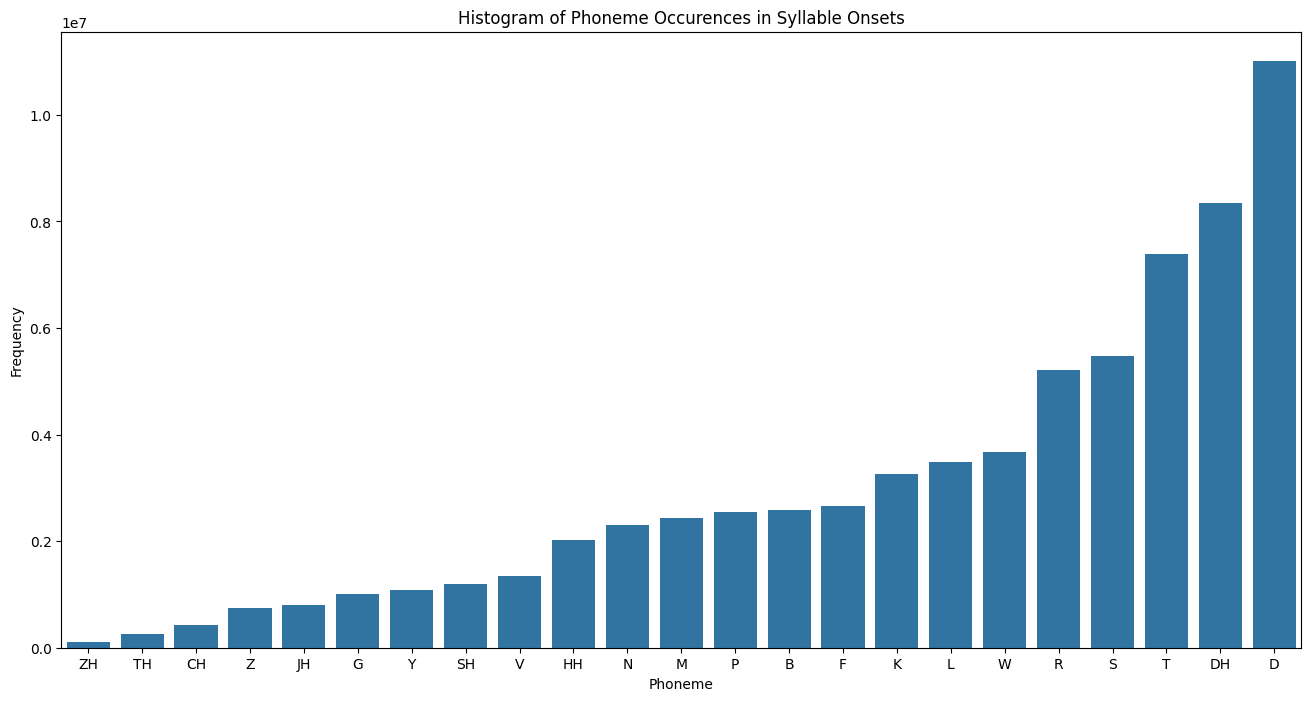

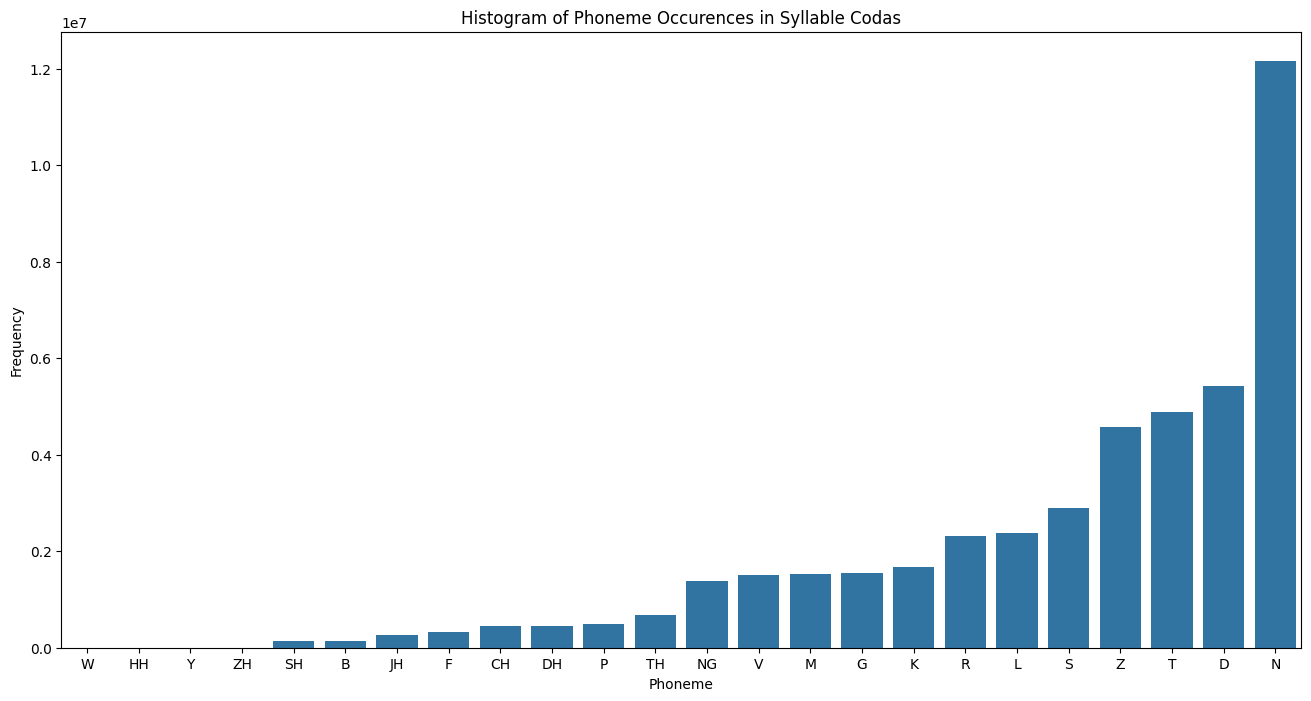

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

df = pl.read_ndjson("../data/onsets.jsonl")
phonemens = pl.read_ndjson("../data/phoneme_set.jsonl")

data = []
for row in phonemens.iter_rows(named=True):
    total = (
        df.filter(pl.col("onset").str.contains(row["phoneme"]))
        .select(pl.col("count"))
        .sum()
        .item()
    )
    if total == 0:
        continue

    data.append({"phoneme": row["phoneme"], "total": total})

df = pl.DataFrame(data).sort(pl.col("total"))

plt.figure(figsize=(16, 8))
sns.barplot(data=df, x="phoneme", y="total")
plt.title("Histogram of Phoneme Occurences in Syllable Onsets")
plt.xlabel("Phoneme")
plt.ylabel("Frequency")

df = pl.read_ndjson("../data/codas.jsonl")

data = []
for row in phonemens.iter_rows(named=True):
    total = (
        df.filter(pl.col("coda").str.contains(row["phoneme"]))
        .select(pl.col("count"))
        .sum()
        .item()
    )
    if total == 0:
        continue

    data.append({"phoneme": row["phoneme"], "total": total})

df = pl.DataFrame(data).sort(pl.col("total"))

plt.figure(figsize=(16, 8))
sns.barplot(data=df, x="phoneme", y="total")
plt.title("Histogram of Phoneme Occurences in Syllable Codas")
plt.xlabel("Phoneme")
plt.ylabel("Frequency")

In [2]:
import numpy as np


def eval_spelling_system(alphabet_df, render):
    onsets_df = pl.read_ndjson("../data/onsets.jsonl").with_columns(
        pl.col("onset").str.split(" ").alias("phonemes")
    )

    glyphs = {}
    onsets = {}
    for onset in onsets_df.iter_rows(named=True):
        keys = []
        phonemens = onset["phonemes"]
        for phoneme in phonemens:
            key = (
                alphabet_df.filter(pl.col("phoneme") == phoneme)
                .select(pl.col("points"))
                .item()
            )
            keys.append(key)

        glyph = render(keys)
        if glyph in glyphs:
            glyphs[glyph].append(onset["count"])
            onsets[glyph].append("".join(phonemens))
        else:
            glyphs[glyph] = [onset["count"]]
            onsets[glyph] = ["".join(phonemens)]

    # count collisions
    total = 0
    collide = 0
    for key, counts in glyphs.items():
        count = sum(counts)
        total += count

        if len(glyphs[key]) > 1:
            collide += count
            print("overlap: ", onsets[key], counts)

    print(f"{(collide / total) * 100:.2f}%")


def render_glyph(keys):
    verts = []
    for k in keys:
        verts.extend(k.split())

    verts = np.unique(verts).tolist()
    return "".join(verts)


file = "../data/alphabets/v1.jsonl"
alphabet_df = pl.read_ndjson(file)
eval_spelling_system(alphabet_df, render_glyph)

overlap:  ['SHH', 'KV'] [1, 273]
overlap:  ['KSY', 'SKY', 'JHY'] [1, 79, 5961]
overlap:  ['ND', 'DN', 'FN'] [1, 1, 417]
overlap:  ['PSH', 'HHW'] [1, 320335]
overlap:  ['CHW', 'YW', 'CHY'] [1, 16, 166]
overlap:  ['NDY', 'FY'] [2, 42948]
overlap:  ['RW', 'SHW', 'SHR'] [3, 1615, 3016]
overlap:  ['SHV', 'SHT'] [3, 487]
overlap:  ['THY', 'SHN'] [3, 29400]
overlap:  ['TSY', 'STY', 'SY', 'TY', 'TS', 'ST'] [3, 800, 1270, 5038, 16876, 719063]
overlap:  ['KLS', 'SKL'] [4, 47]
overlap:  ['HHR', 'PR'] [31, 586584]
overlap:  ['TSR', 'STR'] [72, 222903]
overlap:  ['SPY', 'SKW'] [95, 13000]
overlap:  ['VW', 'TR'] [964, 362457]
overlap:  ['SHM', 'VL'] [4649, 21558]
overlap:  ['ZHW', 'PL'] [5648, 222653]
overlap:  ['SHL', 'ZL'] [7480, 10424]
overlap:  ['SPR', 'SKR'] [8045, 10968]
overlap:  ['DM', 'SM'] [21755, 51245]
overlap:  ['PY', 'KW'] [34914, 134080]
overlap:  ['SL', 'MY'] [62987, 67448]
overlap:  ['DY', 'LY'] [65267, 97922]
5.99%


In [3]:
file = "../data/alphabets/v2.jsonl"
alphabet_df = pl.read_ndjson(file)
eval_spelling_system(alphabet_df, render_glyph)

overlap:  ['SHH', 'KV'] [1, 273]
overlap:  ['KSY', 'SKY', 'SPY', 'JHY', 'SP'] [1, 79, 95, 5961, 257692]
overlap:  ['ND', 'DN', 'FN'] [1, 1, 417]
overlap:  ['PSH', 'HHW'] [1, 320335]
overlap:  ['CHW', 'YW', 'CHY'] [1, 16, 166]
overlap:  ['NDY', 'FY'] [2, 42948]
overlap:  ['RW', 'SHW', 'SHR'] [3, 1615, 3016]
overlap:  ['SHV', 'SHT'] [3, 487]
overlap:  ['TSY', 'STY', 'TY', 'SW'] [3, 800, 5038, 24194]
overlap:  ['KLS', 'SKL'] [4, 47]
overlap:  ['HHR', 'PR'] [31, 586584]
overlap:  ['TSR', 'STR'] [72, 222903]
overlap:  ['ZY', 'DR'] [351, 117642]
overlap:  ['VW', 'TR'] [964, 362457]
overlap:  ['SR', 'VY'] [2824, 32611]
overlap:  ['SHM', 'VL'] [4649, 21558]
overlap:  ['ZHW', 'PL'] [5648, 222653]
overlap:  ['SHL', 'ZL'] [7480, 10424]
overlap:  ['SPR', 'SKR'] [8045, 10968]
overlap:  ['TS', 'ST'] [16876, 719063]
overlap:  ['HHY', 'KR'] [17156, 261749]
overlap:  ['DM', 'SM'] [21755, 51245]
overlap:  ['DW', 'LY'] [22658, 97922]
overlap:  ['PY', 'KY'] [34914, 88456]
6.85%


In [4]:
def get_sequence(verts):
    if len(verts) == 1:
        return [verts]

    sequences = []
    for vert in verts:
        remain = [v for v in verts if v != vert]
        for seq in get_sequence(remain):
            sequences.append([vert] + seq)

    return sequences


verts = [1, 2, 3, 4, 5, 6, 7, 8]
sequences = get_sequence(verts)
print("sequences:", len(sequences))

double = (
    pl.DataFrame(sequences, orient="row")
    .with_columns(
        pl.concat_list(
            pl.col("column_0").cast(pl.String), pl.col("column_1").cast(pl.String)
        ).alias("combined")
    )
    .unique(pl.col("combined"))
    .select(pl.col("combined"))
    .sort(pl.col("combined"))
    .to_series()
    .to_list()
)

sorted_double = [" ".join(sorted(d)) for d in double]
unique_double = np.unique(sorted_double).tolist()
print(f"found {len(unique_double)} doubles\n", unique_double)

sequences: 40320
found 28 doubles
 ['1 2', '1 3', '1 4', '1 5', '1 6', '1 7', '1 8', '2 3', '2 4', '2 5', '2 6', '2 7', '2 8', '3 4', '3 5', '3 6', '3 7', '3 8', '4 5', '4 6', '4 7', '4 8', '5 6', '5 7', '5 8', '6 7', '6 8', '7 8']


In [5]:
import polars as pl

phonemens_df = pl.read_ndjson("../data/phoneme_set.jsonl").filter(pl.col("classification") != "vowel")

def build_alphabet(ps, ds):
    alphabets = []
    for p in ps:
        for d in ds:
            got = {"phoneme": p, "points": d}
            a = [r for r in ps if r != p]
            b = [r for r in ds if r != d]
            assert len(a) < len(ps)
            assert len(b) < len(ds)

            built = build_alphabet(
                a,
                b,
            )

            for b in built:
                alphabets.append(b + [got])
            
            if len(alphabets) == 0:
                alphabets.append([got])


    return alphabets

phonemens = phonemens_df.select(pl.col("phoneme")).to_series().to_list()[:7]
print("phonemes:", phonemens)

doubles = unique_double[:7]
print("doubles:", doubles)

alphabets = build_alphabet(phonemens, doubles)
print(f"{len(alphabets):,}")
print(alphabets[0])

phonemes: ['W', 'Y', 'L', 'R', 'M', 'N', 'NG']
doubles: ['1 2', '1 3', '1 4', '1 5', '1 6', '1 7', '1 8']
25,401,600
[{'phoneme': 'NG', 'points': '1 8'}, {'phoneme': 'N', 'points': '1 7'}, {'phoneme': 'M', 'points': '1 6'}, {'phoneme': 'R', 'points': '1 5'}, {'phoneme': 'L', 'points': '1 4'}, {'phoneme': 'Y', 'points': '1 3'}, {'phoneme': 'W', 'points': '1 2'}]
